In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.signal import welch as welch

In [2]:
T1_vs_Temp = []

In [3]:
data = np.load("data/2026-06-03/#1199_T1_histogram_183344/arrays.npz")

T1_vector = data["T1_values"]
tau_vector = 4 * data["taus"]
I_matrix = data["I_all"]
Q_matrix = data["Q_all"]


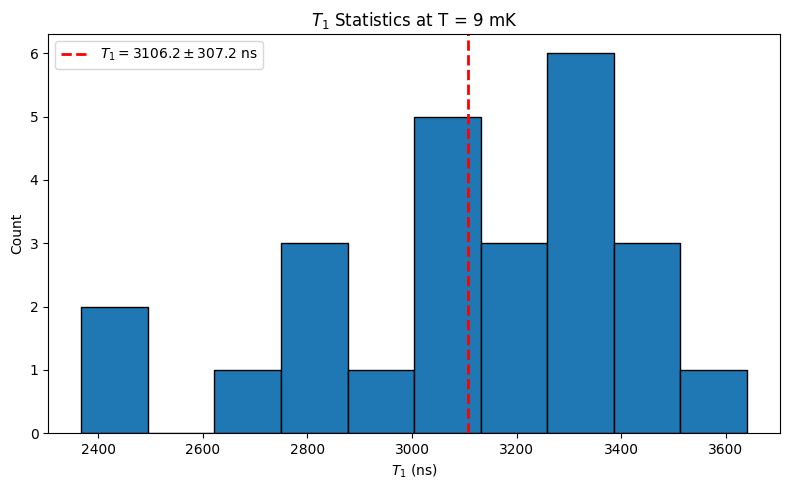

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 9

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 9 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

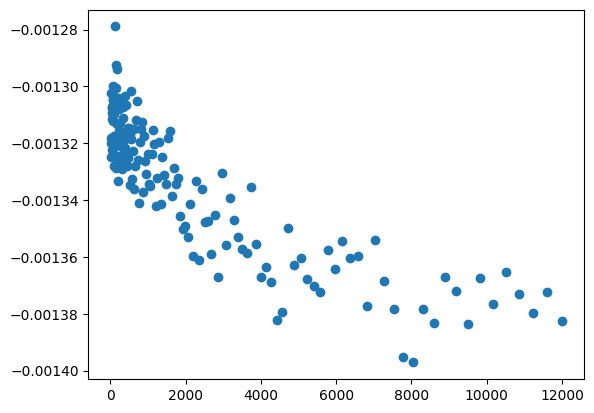

In [5]:
idx = np.argmin(np.abs(T1_vector - 3600))
T1_val = T1_vector[idx]

I_vector = I_matrix[idx,:]
Q_vector = Q_matrix[idx,:]

plt.scatter(tau_vector, I_vector)

In [6]:
I_vector

array([-0.00132483, -0.00132005, -0.00130229, -0.00131826, -0.00131973,
       -0.00130932, -0.00130738, -0.0013113 , -0.00130758, -0.00132236,
       -0.00130935, -0.00130956, -0.00130462, -0.00131223, -0.0013043 ,
       -0.00129984, -0.00130657, -0.00132792, -0.00130367, -0.00130548,
       -0.0013244 , -0.00130974, -0.00131752, -0.00132115, -0.00127892,
       -0.00131924, -0.0013175 , -0.0013055 , -0.00132458, -0.00132047,
       -0.00130049, -0.00129265, -0.00132876, -0.00130397, -0.00130617,
       -0.00130591, -0.00131319, -0.00130394, -0.00129392, -0.00132449,
       -0.00132016, -0.00130396, -0.00131728, -0.00133311, -0.00130808,
       -0.00131571, -0.00132653, -0.00131272, -0.00132431, -0.00132509,
       -0.00132553, -0.00130457, -0.00132607, -0.00131876, -0.00132114,
       -0.0013292 , -0.00130734, -0.00131126, -0.001316  , -0.00131874,
       -0.00131689, -0.00130352, -0.00132169, -0.00130663, -0.00132441,
       -0.00132793, -0.00132524, -0.00131465, -0.00131473, -0.00

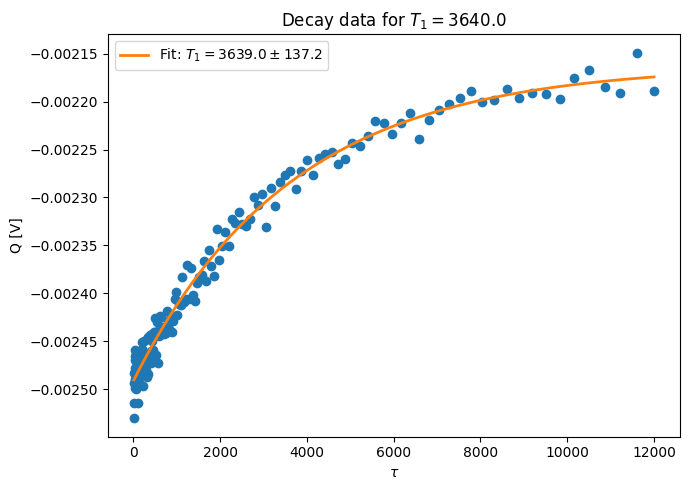

In [7]:
# Find closest T1 value
idx = np.argmin(np.abs(T1_vector - 3600))
T1_val = T1_vector[idx]

I_vector = I_matrix[idx, :]
Q_vector = Q_matrix[idx, :]

# Exponential decay model
def exp_decay(t, A, T1, C):
    return A * np.exp(-t / T1) + C

# Initial guesses
p0 = [
    np.max(Q_vector) - np.min(Q_vector),  # A
    tau_vector.max() / 2,                 # T1
    np.min(Q_vector)                      # C
]

# Fit
popt, pcov = curve_fit(exp_decay, tau_vector, Q_vector, p0=p0)

A_fit, T1_fit, C_fit = popt
T1_err = np.sqrt(np.diag(pcov))[1]

# Smooth fit curve
tau_fit = np.linspace(tau_vector.min(), tau_vector.max(), 500)
Q_fit = exp_decay(tau_fit, *popt)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(tau_vector, Q_vector, color="C0")
ax.plot(
    tau_fit,
    Q_fit,
    color="C1",
    lw=2,
    label=rf"Fit: $T_1 = {T1_fit:.1f} \pm {T1_err:.1f}$"
)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Q [V]")
ax.set_title(rf"Decay data for $T_1 = {T1_val:.1f}$")

# # Display fitted exponent on plot
# ax.text(
#     0.05,
#     0.95,
#     rf"$Q(\tau) = {A_fit:.3g} e^{{-\tau/{T1_fit:.1f}}} + {C_fit:.3g}$",
#     transform=ax.transAxes,
#     va="top",
#     bbox=dict(facecolor="white", alpha=0.8)
# )

ax.legend()
fig.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [9]:
data = np.load("data/2026-06-03/#1204_T1_histogram_190829/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V


In [10]:
T1_vector

array([ 2280.,  2580.,  2072.,  2168.,  2184.,  2632.,  2292.,  2528.,
        1816.,  2100.,  2084.,  2068.,  2272.,  2904.,  1736.,  1648.,
        2248.,  1760.,   844.,  7268.,  3996.,  3752.,  8560.,  2988.,
         756.,  1668.,  2300., 10812.,  3204.,   820.])

In [11]:
I_matrix[:,0]

array([-0.00126175, -0.00127008, -0.00129082, -0.00125352, -0.00127122,
       -0.00128181, -0.0012855 , -0.00127651, -0.00128299, -0.00133854,
       -0.00139519, -0.00140155, -0.00139421, -0.00141321, -0.0013977 ,
       -0.00139107, -0.00139447, -0.00140936, -0.00142501, -0.00141718,
       -0.00142604, -0.00139392, -0.00140773, -0.00140372, -0.00141645,
       -0.00142366, -0.00140653, -0.00140101, -0.001403  , -0.0013976 ])

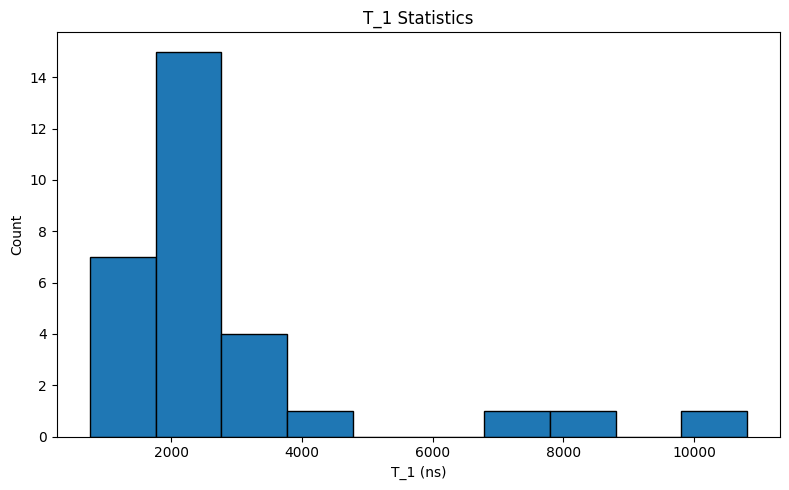

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.set_title("T_1 Statistics")
ax.set_xlabel("T_1 (ns)")
ax.set_ylabel("Count")

fig.tight_layout()

plt.show()

In [13]:
data = np.load("data/2026-06-04/#1210_T1_histogram_103805/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V


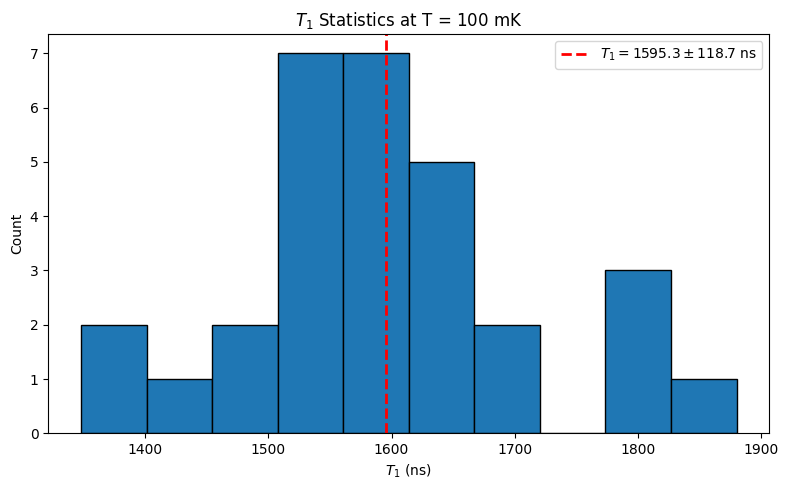

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 100

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 100 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [15]:
data = np.load("data/2026-06-04/#1213_T1_histogram_112311/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V


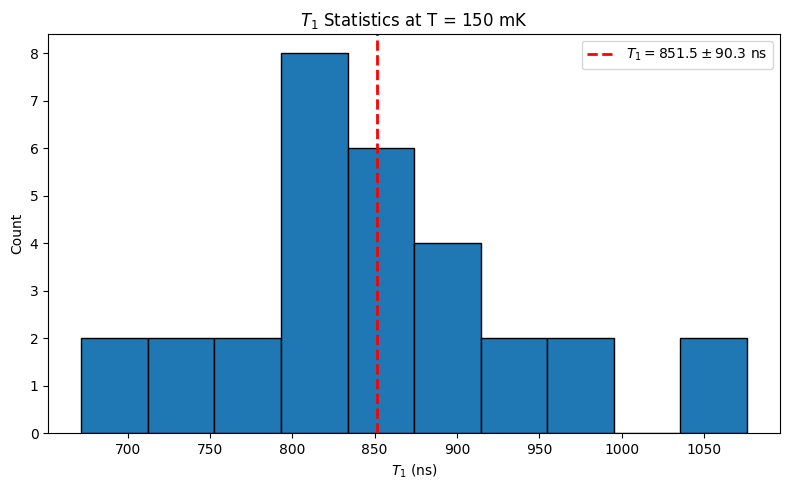

In [16]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 150

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 150 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [17]:
data = np.load("data/2026-06-04/#1218_T1_histogram_141437/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V

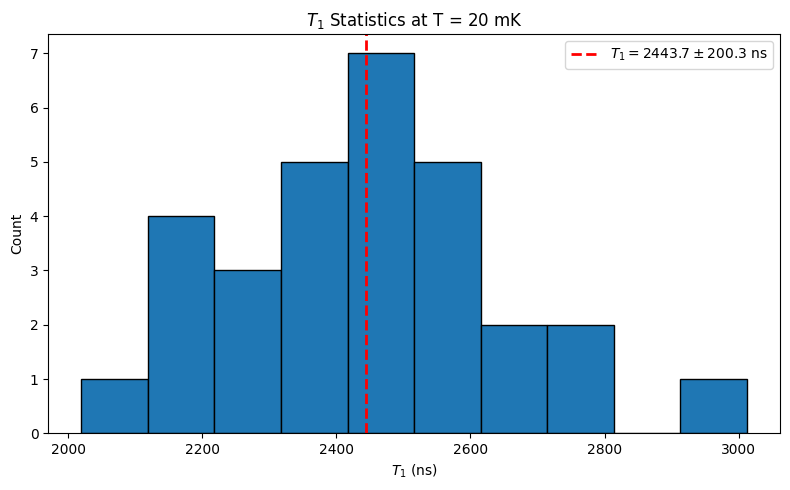

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 20

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 20 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [19]:
data = np.load("data/2026-06-04/#1221_T1_histogram_143802/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V

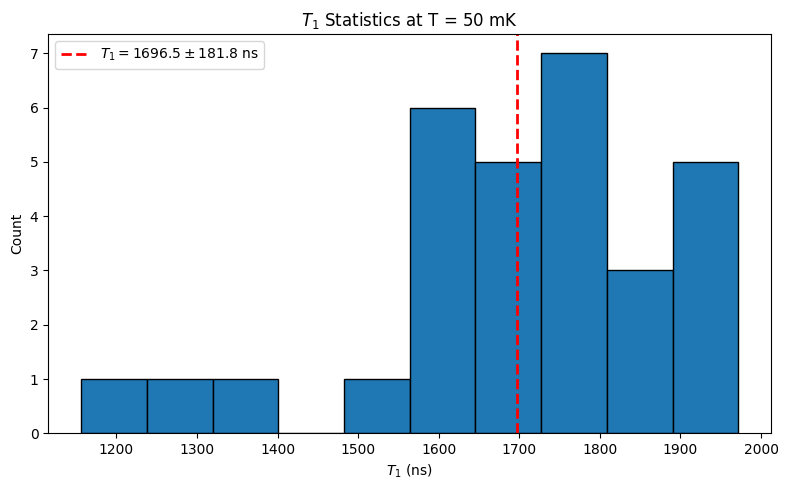

In [20]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 50

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 50 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [21]:
data = np.load("data/2026-06-04/#1228_T1_histogram_150230/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V

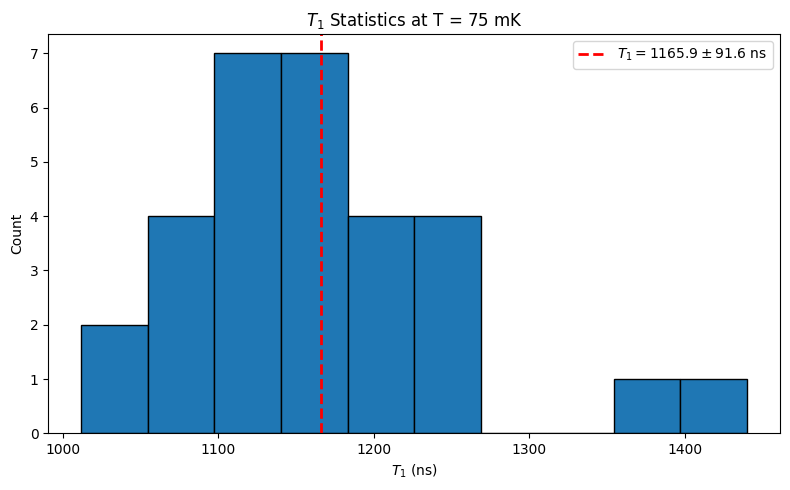

In [22]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 75

T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=10, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 75 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [23]:
data = np.load("data/2026-06-05/#1246_T1_histogram_105418/arrays.npz")

T1_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V

In [24]:
T1_vector

array([1060., 1020., 1000., 1012., 1088.,  984., 1040.,  928., 1108.,
       1024., 1008., 1100., 1132., 1012., 1028., 1008., 1060., 1052.,
        968., 1096., 1404.,  748., 2184.])

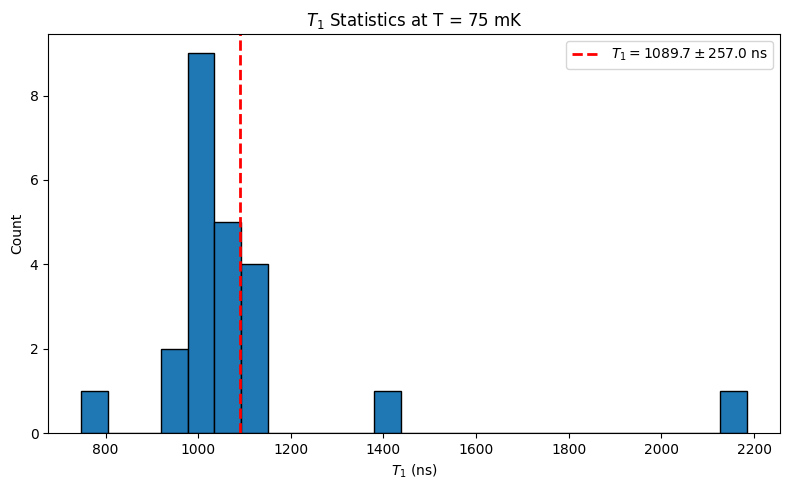

In [25]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T1_ave = np.mean(T1_vector)
T1_std = np.std(T1_vector)
Temp = 75

# T1_vs_Temp.append([Temp, T1_ave, T1_std])

ax.hist(T1_vector, bins=25, edgecolor="black")

ax.axvline(
    T1_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_1 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_1$ Statistics at T = 75 mK")
ax.set_xlabel(r"$T_1$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [26]:
# # Exponential decay model
# def exp_decay(t, A, T1, C):
#     return A * np.exp(-t / T1) + C

# for idx in range(len(T1_vector)):

#     T1_val = T1_vector[idx]

#     I_vector = I_matrix[idx, :]
#     Q_vector = Q_matrix[idx, :]

#     # Initial guesses
#     p0 = [
#         np.max(Q_vector) - np.min(Q_vector),
#         tau_vector.max() / 2,
#         np.min(Q_vector)
#     ]

#     try:
#         # Fit
#         popt, pcov = curve_fit(
#             exp_decay,
#             tau_vector,
#             Q_vector,
#             p0=p0,
#             maxfev=10000
#         )

#         A_fit, T1_fit, C_fit = popt
#         T1_err = np.sqrt(np.diag(pcov))[1]

#         # Smooth fit curve
#         tau_fit = np.linspace(
#             tau_vector.min(),
#             tau_vector.max(),
#             500
#         )
#         Q_fit = exp_decay(tau_fit, *popt)

#         # New figure for this decay
#         fig, ax = plt.subplots(figsize=(7, 5))

#         ax.scatter(
#             tau_vector,
#             Q_vector,
#             color="C0"
#         )

#         ax.plot(
#             tau_fit,
#             Q_fit,
#             color="C1",
#             lw=2,
#             label=rf"Fit: $T_1 = {T1_fit:.1f} \pm {T1_err:.1f}$"
#         )

#         ax.set_xlabel(r"$\tau$")
#         ax.set_ylabel("Q [V]")
#         ax.set_title(rf"Decay data for $T_1 = {T1_val:.1f}$")

#         ax.legend()

#         fig.tight_layout()
#         plt.show()

#     except RuntimeError:
#         print(f"Fit failed for T1 = {T1_val}")

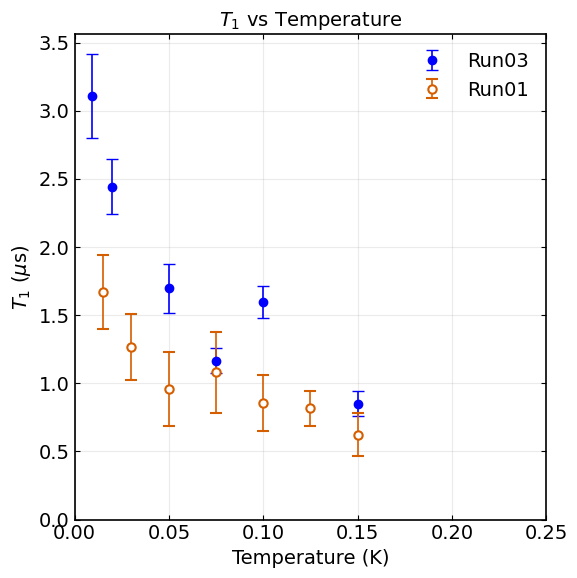

In [27]:
# Run01 Data from Jesse
Temp_vector_old = np.array([0.015, 0.030, 0.050, 0.075, 0.100, 0.125, 0.150])
T1_ave_vector_old = np.array([1.6690, 1.2642, 0.9547, 1.0807, 0.8547, 0.8161, 0.6225])
T1_std_vector_old = np.array([0.2712, 0.2411, 0.2716, 0.2962, 0.2044, 0.1308, 0.1591])

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

T1_vs_Temp = np.array(T1_vs_Temp)

# Convert units
Temp_vector = T1_vs_Temp[:, 0] / 1000      # mK -> K
T1_ave_vector = T1_vs_Temp[:, 1] / 1000    # ns -> us
T1_std_vector = T1_vs_Temp[:, 2] / 1000    # ns -> us

fig, ax = plt.subplots(figsize=(6, 6))

# New data
ax.errorbar(
    Temp_vector,
    T1_ave_vector,
    yerr=T1_std_vector,
    fmt='o',
    color='b',
    mfc='b',
    mec='b',
    ms=6,
    capsize=4,
    elinewidth=1.2,
    label='Run03'
)

# Previous data
ax.errorbar(
    Temp_vector_old,
    T1_ave_vector_old,
    yerr=T1_std_vector_old,
    fmt='o',
    color='#D55E00',      # colorblind-safe orange
    mfc='white',
    mec='#D55E00',
    mew=1.5,
    ms=6,
    capsize=4,
    elinewidth=1.2,
    label='Run01'
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$T_1$ ($\mu$s)")
ax.set_title(r"$T_1$ vs Temperature")

ax.set_xlim(0.00, 0.25)
ax.set_ylim(bottom=0)

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.tick_params(direction='in', top=True, right=True)

ax.legend(frameon=False)

fig.tight_layout()
plt.show()

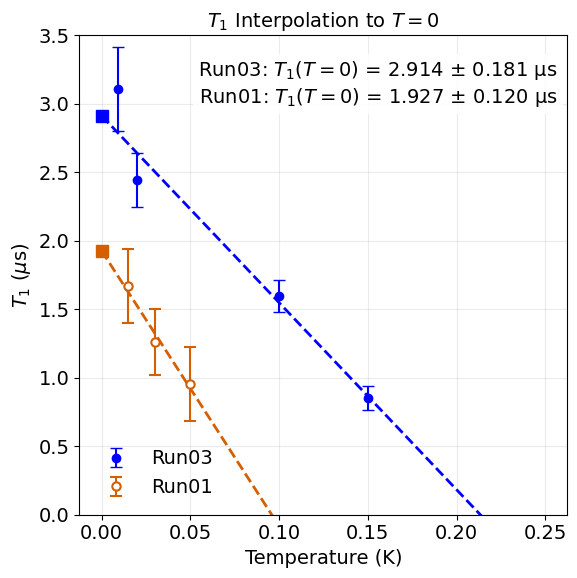

Run03: T1(T = 0) = 2.913577 ± 0.181093 μs
Run01: T1(T = 0) = 1.927191 ± 0.119799 μs


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Select points
Run03_T = Temp_vector[:4]
Run03_T1 = T1_ave_vector[:4]
Run03_T1_err = T1_std_vector[:4]

Run01_T = Temp_vector_old[:3]
Run01_T1 = T1_ave_vector_old[:3]
Run01_T1_err = T1_std_vector_old[:3]

# Weighted linear fits
p_Run03, cov_Run03 = np.polyfit(
    Run03_T,
    Run03_T1,
    1,
    w=1/Run03_T1_err,
    cov=True
)

p_Run01, cov_Run01 = np.polyfit(
    Run01_T,
    Run01_T1,
    1,
    w=1/Run01_T1_err,
    cov=True
)

m_Run03, b_Run03 = p_Run03
m_Run01, b_Run01 = p_Run01

# 1-sigma uncertainties
merr_Run03, berr_Run03 = np.sqrt(np.diag(cov_Run03))
merr_Run01, berr_Run01 = np.sqrt(np.diag(cov_Run01))

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.errorbar(
    Run03_T,
    Run03_T1,
    yerr=Run03_T1_err,
    fmt='o',
    color='b',
    mfc='b',
    mec='b',
    ms=6,
    capsize=4,
    label='Run03'
)

ax.errorbar(
    Run01_T,
    Run01_T1,
    yerr=Run01_T1_err,
    fmt='o',
    color='#D55E00',
    mfc='white',
    mec='#D55E00',
    mew=1.5,
    ms=6,
    capsize=4,
    label='Run01'
)

ax.set_ylim(0.0,3.5)

# Fit lines
xfit = np.linspace(0, 0.25, 200)

ax.plot(
    xfit,
    m_Run03 * xfit + b_Run03,
    '--',
    color='b',
    lw=2
)

ax.plot(
    xfit,
    m_Run01 * xfit + b_Run01,
    '--',
    color='#D55E00',
    lw=2
)

# Mark y intercepts
ax.plot(0, b_Run03, 's', color='b', ms=8)
ax.plot(0, b_Run01, 's', color='#D55E00', ms=8)

# Annotate
ax.text(
    0.98,
    0.95,
    (
        f'Run03: $T_1(T = 0)$ = {b_Run03:.3f} ± {berr_Run03:.3f} μs\n'
        f'Run01: $T_1(T = 0)$ = {b_Run01:.3f} ± {berr_Run01:.3f} μs'
    ),
    transform=ax.transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none')
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$T_1$ ($\mu$s)")
ax.set_title(r"$T_1$ Interpolation to $T = 0$")

ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

print(f"Run03: T1(T = 0) = {b_Run03:.6f} ± {berr_Run03:.6f} μs")
print(f"Run01: T1(T = 0) = {b_Run01:.6f} ± {berr_Run01:.6f} μs")

In [29]:
data = np.load("data/2026-06-09/#1319_resonator_spectroscopy_141102/arrays.npz")

freq_vector = data["frequency"]
I_vector_RO = data["I_data"]
Q_vector_RO = data["Q_data"]

S21_RO = I_vector_RO + 1j * Q_vector_RO
S21_mag_RO = np.abs(S21_RO)
S21_mag_dB_RO = 10 * np.log10(np.abs(S21_RO) ** 2)

In [30]:
data = np.load("data/2026-06-09/#1318_resonator_spectroscopy_pi_pulse_141038/arrays.npz")

freq_vector = data["frequency"]
I_vector_PI_RO = data["I_data"]
Q_vector_PI_RO = data["Q_data"]

S21_PI_RO = I_vector_PI_RO + 1j * Q_vector_PI_RO
S21_mag_PI_RO = np.abs(S21_PI_RO)
S21_mag_dB_PI_RO = 10 * np.log10(np.abs(S21_PI_RO) ** 2)

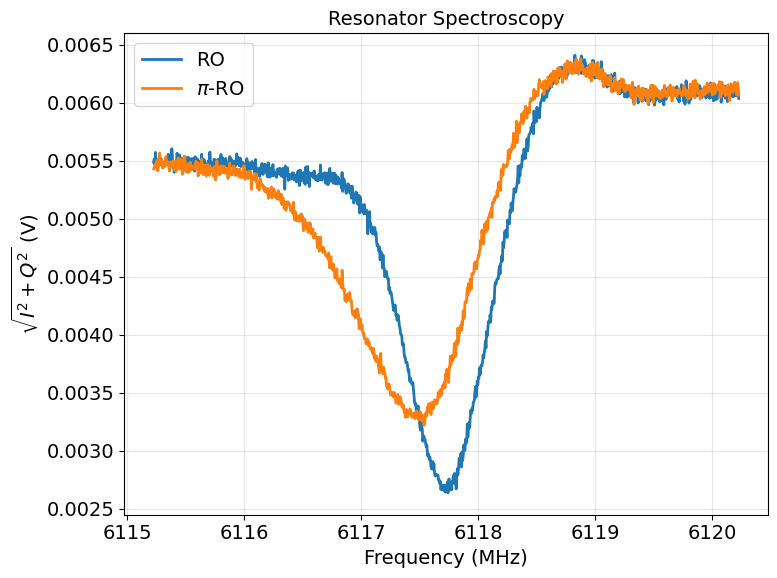

f_RO    = 6117.740015 MHz
f_π-RO  = 6117.535015 MHz
χ       = -0.102500 MHz


In [31]:
plt.figure(figsize=(8, 6))

plt.plot(freq_vector / 1e6, S21_mag_RO, label="RO", lw=2)
plt.plot(freq_vector / 1e6, S21_mag_PI_RO, label=r"$\pi$-RO", lw=2)

plt.xlabel("Frequency (MHz)")
plt.ylabel(r"$\sqrt{I^2 + Q^2}$ (V)")
plt.title("Resonator Spectroscopy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# calculate \chi
f_RO = freq_vector[np.argmin(S21_mag_dB_RO)]
f_PI_RO = freq_vector[np.argmin(S21_mag_dB_PI_RO)]

chi = (f_PI_RO - f_RO) / 2

print(f"f_RO    = {f_RO/1e6:.6f} MHz")
print(f"f_π-RO  = {f_PI_RO/1e6:.6f} MHz")
print(f"χ       = {chi/1e6:.6f} MHz")

In [32]:
data = np.load("data/2026-06-11/#1383_qubit_spectroscopy_x180_saturation_094822/arrays.npz")

freq_vector_x180_sat = data["frequency"]
I_vector_x180_sat = data["I_data"]
Q_vector_x180_sat = data["Q_data"]

S21_mag_x180_sat = np.sqrt(I_vector_x180_sat**2 + Q_vector_x180_sat**2)
S21_phase_x180_sat = np.arctan(Q_vector_x180_sat / I_vector_x180_sat)

data = np.load("data/2026-06-11/#1382_qubit_spectroscopy_x180_094350/arrays.npz")

freq_vector_x180 = data["frequency"]
I_vector_x180 = data["I_data"]
Q_vector_x180 = data["Q_data"]

S21_mag_x180 = np.sqrt(I_vector_x180**2 + Q_vector_x180**2)
S21_phase_x180 = np.arctan(Q_vector_x180 / I_vector_x180)



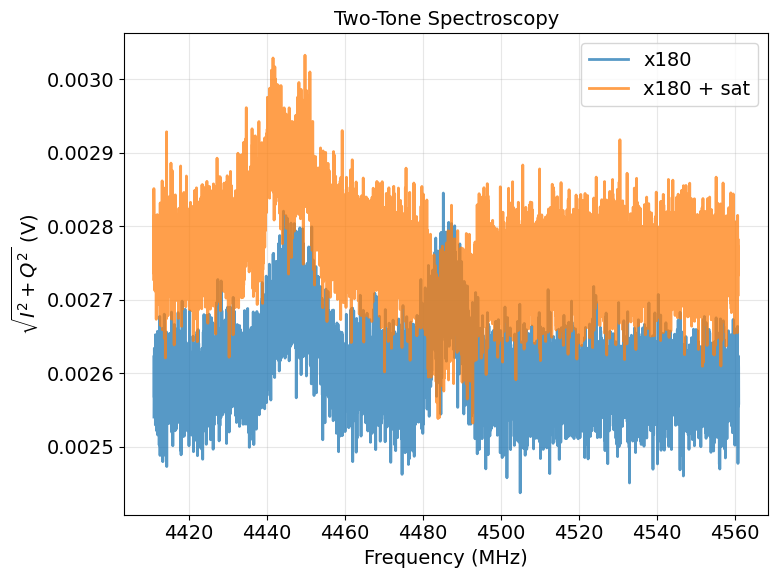

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(freq_vector_x180 / 1e6, S21_mag_x180, label="x180", lw=2, alpha=0.75)
plt.plot(freq_vector_x180_sat /1e6, S21_mag_x180_sat, label=r"x180 + sat", lw=2, alpha=0.75)

plt.xlim()

plt.xlabel("Frequency (MHz)")
plt.ylabel(r"$\sqrt{I^2 + Q^2}$ (V)")
plt.title("Two-Tone Spectroscopy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

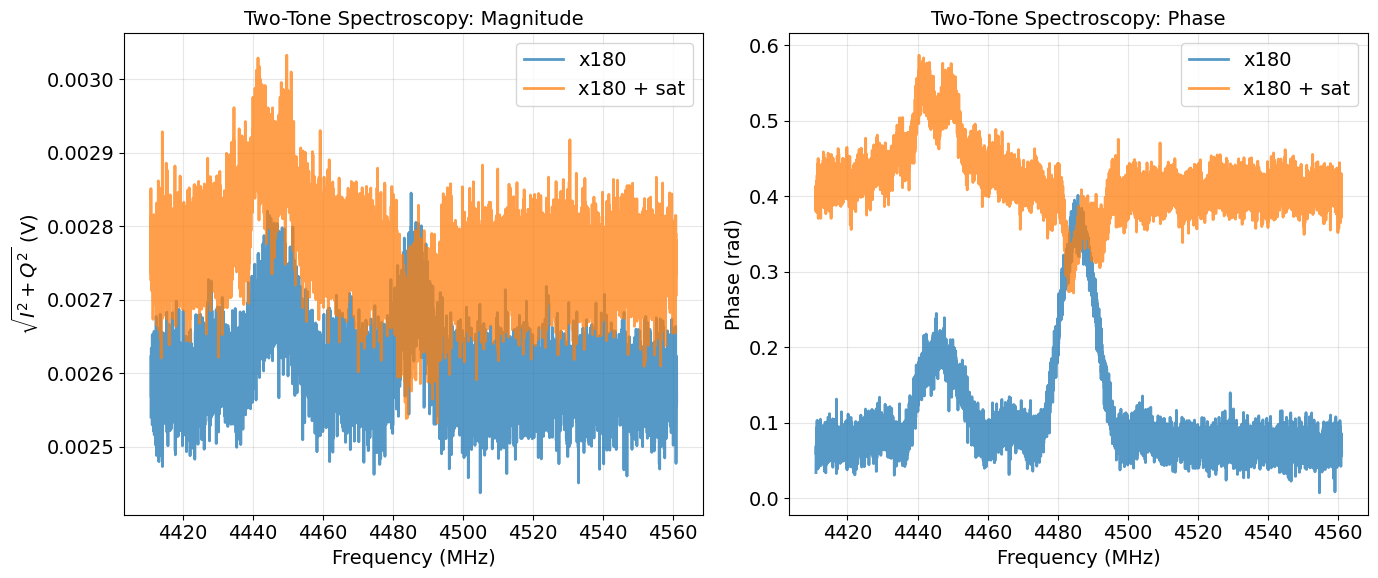

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# Magnitude plot
# =========================
axes[0].plot(
    freq_vector_x180 / 1e6,
    S21_mag_x180,
    label="x180",
    lw=2,
    alpha=0.75,
)

axes[0].plot(
    freq_vector_x180_sat / 1e6,
    S21_mag_x180_sat,
    label=r"x180 + sat",
    lw=2,
    alpha=0.75,
)

axes[0].set_xlabel("Frequency (MHz)")
axes[0].set_ylabel(r"$\sqrt{I^2 + Q^2}$ (V)")
axes[0].set_title("Two-Tone Spectroscopy: Magnitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =========================
# Phase plot
# =========================
axes[1].plot(
    freq_vector_x180 / 1e6,
    S21_phase_x180,
    label="x180",
    lw=2,
    alpha=0.75,
)

axes[1].plot(
    freq_vector_x180_sat / 1e6,
    S21_phase_x180_sat,
    label=r"x180 + sat",
    lw=2,
    alpha=0.75,
)

axes[1].set_xlabel("Frequency (MHz)")
axes[1].set_ylabel("Phase (rad)")
axes[1].set_title("Two-Tone Spectroscopy: Phase")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
data = np.load("data/2026-06-12/#1402_qubit_spectroscopy_vs_amplitude_f12_004113/arrays.npz")

freq_vector = data["frequency"]
amp_vector = data["amplitude"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.sqrt(I_matrix**2 + Q_matrix**2)

In [36]:
data

NpzFile 'data/2026-06-12/#1402_qubit_spectroscopy_vs_amplitude_f12_004113/arrays.npz' with keys: amplitude, frequency, I_data, Q_data

In [37]:
I_matrix

array([[0.00252684, 0.00251835, 0.00251278, ..., 0.00256585, 0.00255346,
        0.00252192],
       [0.00252661, 0.00255214, 0.00255408, ..., 0.00255024, 0.00256125,
        0.00258526],
       [0.00252466, 0.00251091, 0.00251008, ..., 0.00254356, 0.00255296,
        0.00255349],
       ...,
       [0.00249697, 0.0025181 , 0.00251942, ..., 0.00253669, 0.00254992,
        0.00253554],
       [0.00252625, 0.00253086, 0.00253777, ..., 0.00252388, 0.00252906,
        0.00253675],
       [0.00251543, 0.0025112 , 0.00248723, ..., 0.00249047, 0.00252856,
        0.00252524]], shape=(3001, 98))

In [38]:
freq_vector

array([4.11264518e+09, 4.11269518e+09, 4.11274518e+09, ...,
       4.26254518e+09, 4.26259518e+09, 4.26264518e+09], shape=(3001,))

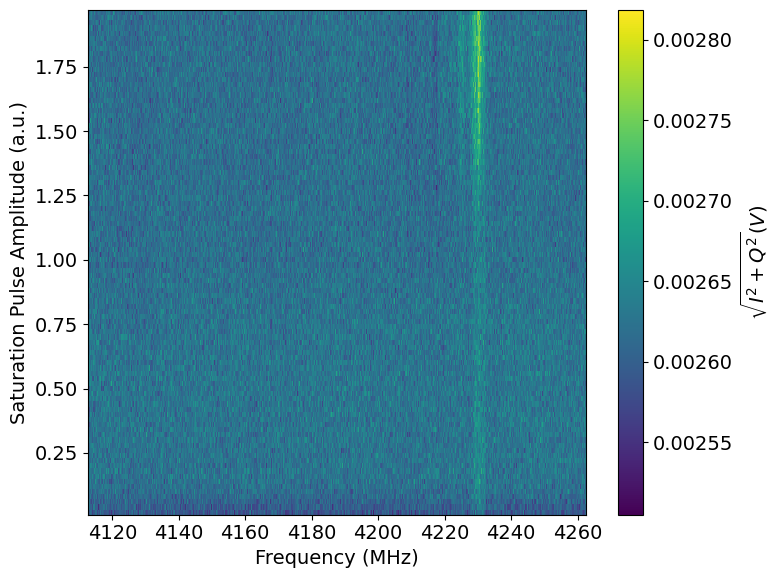

In [39]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    amp_vector,
    S21_mag.T,
    shading="auto"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Saturation Pulse Amplitude (a.u.)")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [40]:
data = np.load("data/2026-06-12/#1404_qubit_spectroscopy_vs_amplitude_f12_111729/arrays.npz")

freq_vector = data["frequency"]
amp_vector = data["amplitude"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.sqrt(I_matrix**2 + Q_matrix**2)

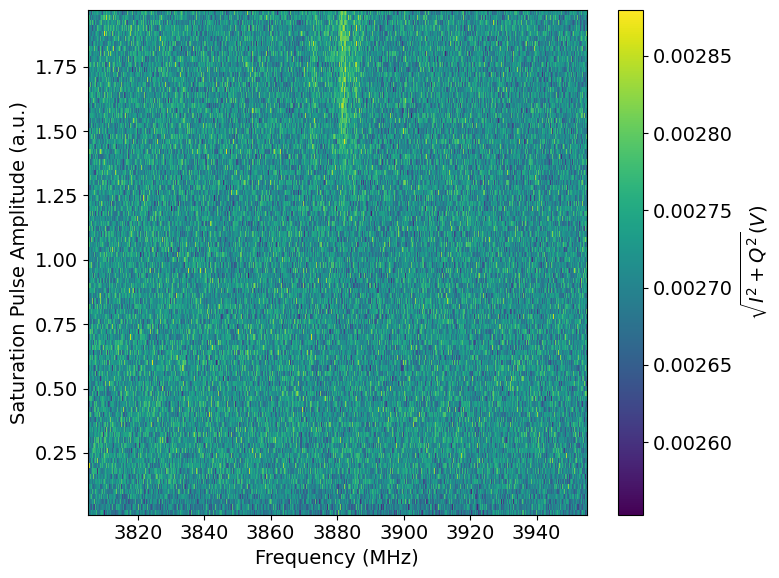

In [41]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    amp_vector,
    S21_mag.T,
    shading="auto"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Saturation Pulse Amplitude (a.u.)")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [42]:
data = np.load("data/2026-06-15/#1473_ramsey_chevron_115015/arrays.npz")

IF_vector = data["IF_frequencies"]
delay_vector = data["taus"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.sqrt(I_matrix**2 + Q_matrix**2)

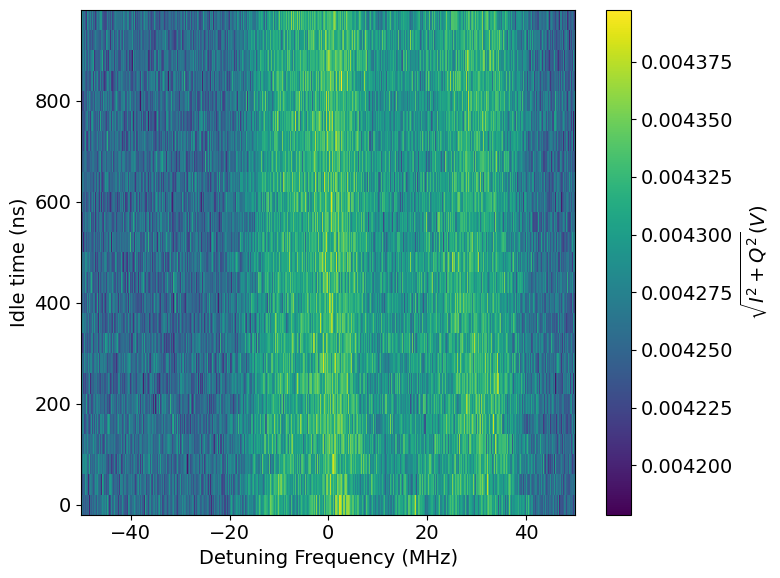

In [43]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    IF_vector/1e6,
    delay_vector*4,
    S21_mag,
    shading="auto"
)

plt.xlabel("Detuning Frequency (MHz)")
plt.ylabel("Idle time (ns)")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [44]:
data = np.load("data/2026-06-15/#1497_qubit_spectroscopy_vs_amplitude_141024/arrays.npz")

qubit_power_dBm = +16

amp_vector = data["amplitude"]
freq_vector = data["frequency"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

power_vector = qubit_power_dBm + 20 * np.log10(amp_vector)

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)

data

NpzFile 'data/2026-06-15/#1497_qubit_spectroscopy_vs_amplitude_141024/arrays.npz' with keys: amplitude, frequency, I_data, Q_data

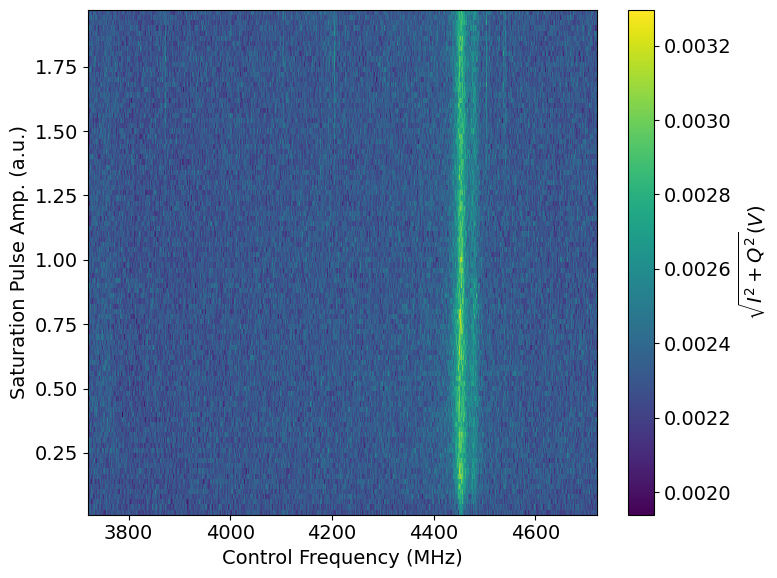

In [45]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    amp_vector,
    S21_mag_matrix.T,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Saturation Pulse Amp. (a.u.)")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

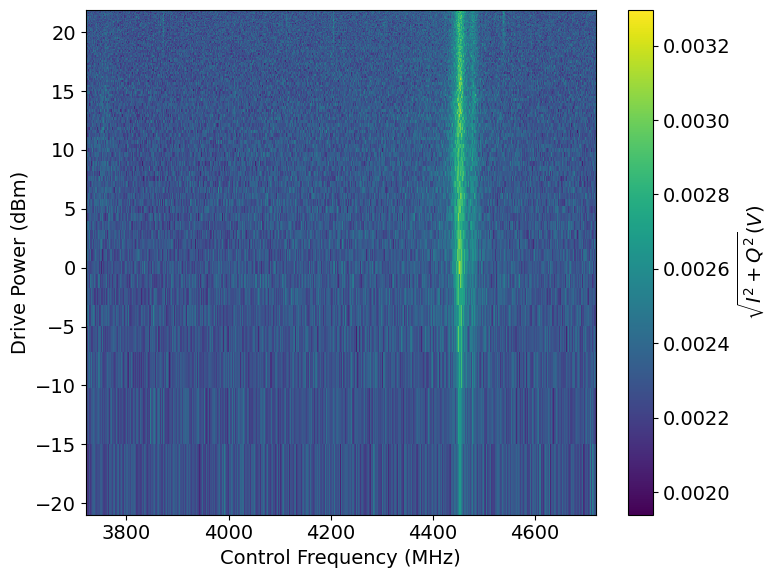

In [46]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    power_vector,
    S21_mag_matrix.T,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Drive Power (dBm)")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

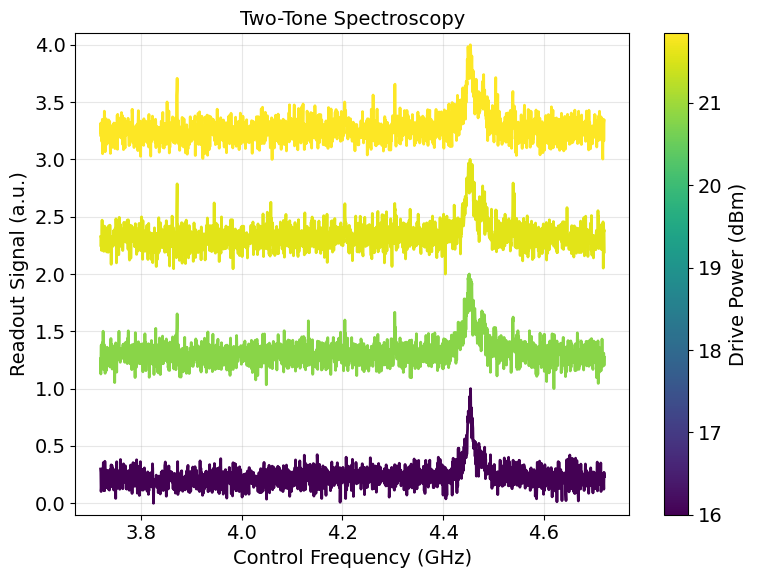

In [47]:
amp1 = 1.00
amp2 = 1.75
amp3 = 1.90
amp4 = 1.96

amps_to_plot = [amp1, amp2, amp3, amp4]

fig, ax = plt.subplots(figsize=(8, 6))

offset_step = 1.0   # important: keep clean separation

powers = []
indices = []

for amp in amps_to_plot:
    idx = np.argmin(np.abs(amp_vector - amp))
    indices.append(idx)
    powers.append(power_vector[idx])

powers = np.array(powers)

norm = colors.Normalize(vmin=powers.min(), vmax=powers.max())
cmap = cm.viridis

for n, idx in enumerate(indices):

    trace = S21_mag_matrix[:, idx]

    # independent normalization (THIS is what papers do)
    trace = trace - np.min(trace)
    trace = trace / np.max(trace)

    ax.plot(
        freq_vector / 1e9,
        trace + n * offset_step,
        color=cmap(norm(power_vector[idx])),
        linewidth=2,
    )

ax.set_xlabel("Control Frequency (GHz)")
ax.set_ylabel("Readout Signal (a.u.)")
ax.set_title("Two-Tone Spectroscopy")
ax.grid(alpha=0.3)

# IMPORTANT: fix visible range so plot doesn't autoscale weirdly
ax.set_ylim(-0.1, offset_step * (len(indices) - 1) + 1.1)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Drive Power (dBm)")

plt.tight_layout()
plt.show()

In [48]:
data = np.load("data/2026-06-17/#1537_time_rabi_chevron_113040/arrays.npz")

freq_vector = data["frequencies"]
pulse_len = data["durations"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)


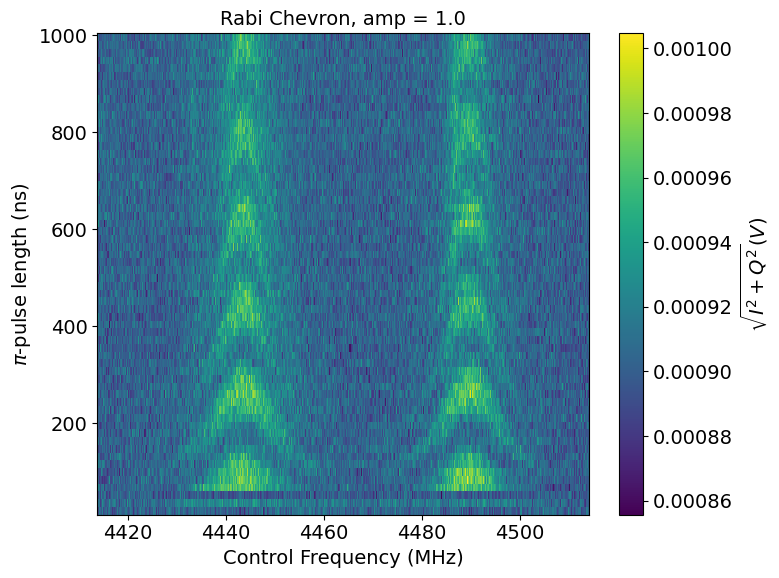

In [49]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    pulse_len*4,
    S21_mag_matrix,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"$\pi$-pulse length (ns)")
plt.title("Rabi Chevron, amp = 1.0")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [50]:
data = np.load("data/2026-06-17/#1538_time_rabi_chevron_113547/arrays.npz")

freq_vector = data["frequencies"]
pulse_len = data["durations"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)


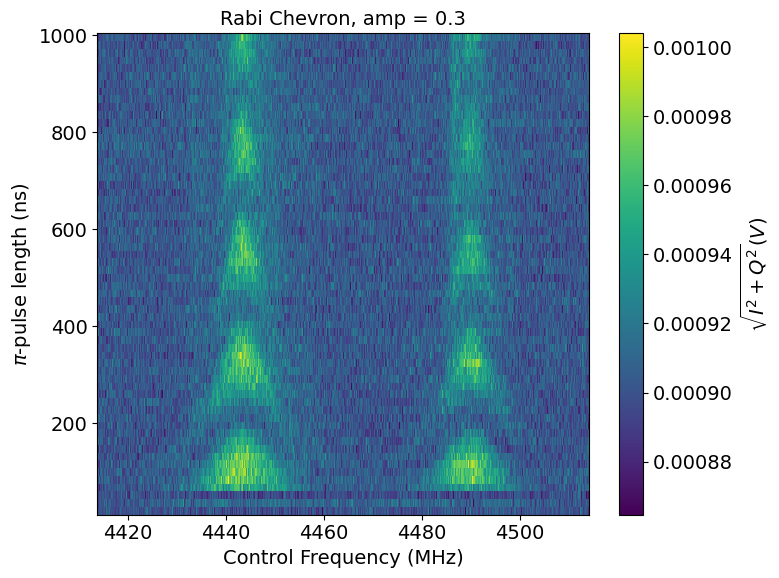

In [51]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    pulse_len*4,
    S21_mag_matrix,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"$\pi$-pulse length (ns)")
plt.title("Rabi Chevron, amp = 0.3")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [52]:
data = np.load("data/2026-06-17/#1548_time_rabi_chevron_133627/arrays.npz")

freq_vector = data["frequencies"]
pulse_len = data["durations"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)



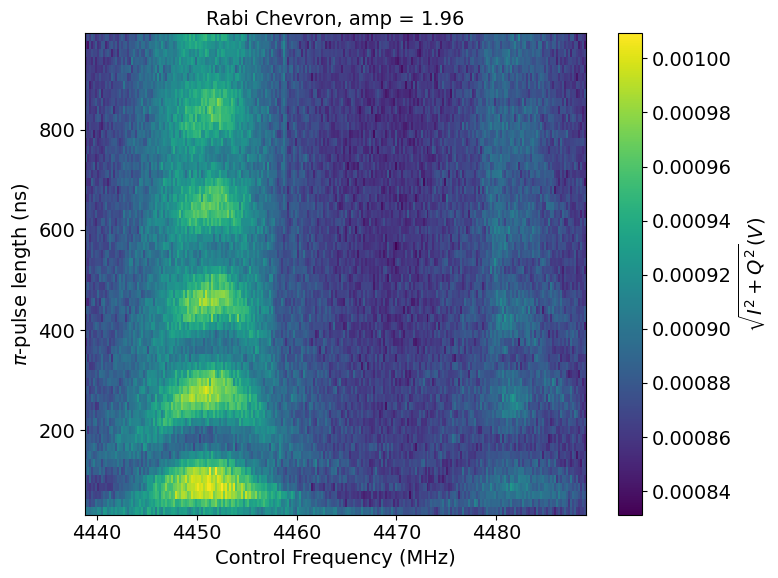

In [53]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    pulse_len*4,
    S21_mag_matrix,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"$\pi$-pulse length (ns)")
plt.title("Rabi Chevron, amp = 1.96")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [54]:
data = np.load("data/2026-06-17/#1543_time_rabi_chevron_115626/arrays.npz")


freq_vector = data["frequencies"]
pulse_len = data["durations"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)


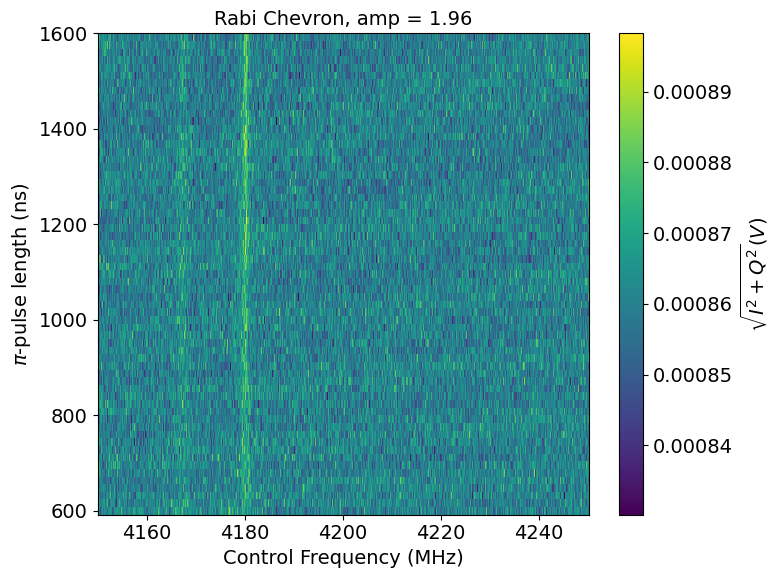

In [55]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    pulse_len*4,
    S21_mag_matrix,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"$\pi$-pulse length (ns)")
plt.title("Rabi Chevron, amp = 1.96")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

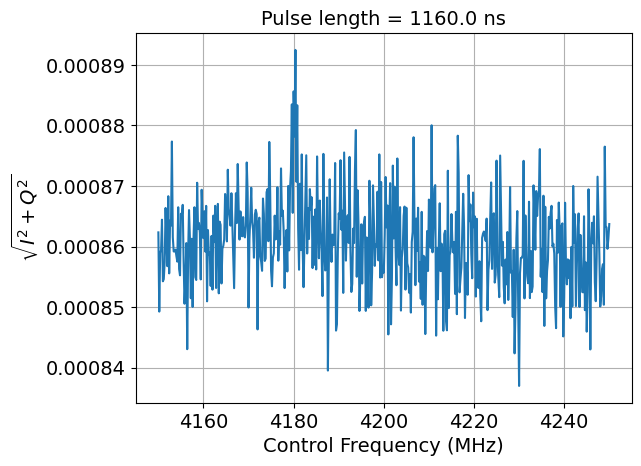

In [56]:
# Choose pulse length (same units as pulse_len)
target_pulse = 1164  # example

y_idx = np.argmin(np.abs(pulse_len*4 - target_pulse))

plt.figure()
plt.plot(freq_vector/1e6, S21_mag_matrix[y_idx, :])
plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"$\sqrt{I^2+Q^2}$")
plt.title(f"Pulse length = {pulse_len[y_idx]*4:.1f} ns")
plt.grid()
plt.show()

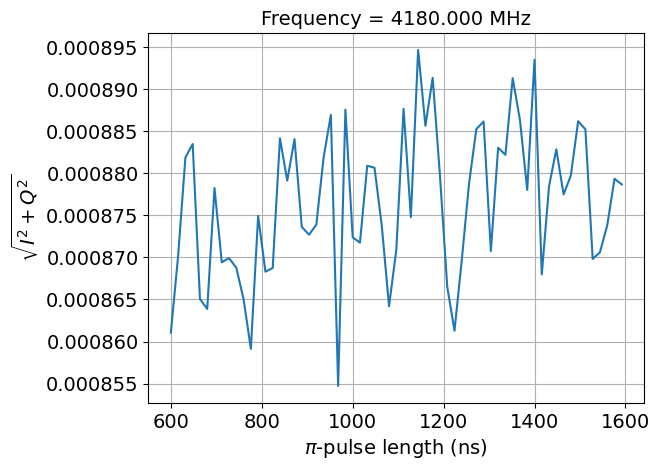

In [57]:
target_freq = 4180  # MHz

x_idx = np.argmin(np.abs(freq_vector/1e6 - target_freq))

plt.figure()
plt.plot(pulse_len*4, S21_mag_matrix[:, x_idx])
plt.xlabel(r"$\pi$-pulse length (ns)")
plt.ylabel(r"$\sqrt{I^2+Q^2}$")
plt.title(f"Frequency = {freq_vector[x_idx]/1e6:.3f} MHz")
plt.grid()
plt.show()

In [58]:
data = np.load("data/2026-06-18/#1722_resonator_spectroscopy_122832/arrays.npz")

freq_vector = data["frequency"]
I_vector_RO = data["I_data"]
Q_vector_RO = data["Q_data"]

S21_RO = I_vector_RO + 1j * Q_vector_RO
S21_mag_RO = np.abs(S21_RO)
S21_mag_dB_RO = 10 * np.log10(np.abs(S21_RO) ** 2)

In [59]:
data = np.load("data/2026-06-18/#1723_resonator_spectroscopy_pi_pulse_122855/arrays.npz")

freq_vector = data["frequency"]
I_vector_PI_RO = data["I_data"]
Q_vector_PI_RO = data["Q_data"]

S21_PI_RO = I_vector_PI_RO + 1j * Q_vector_PI_RO
S21_mag_PI_RO = np.abs(S21_PI_RO)
S21_mag_dB_PI_RO = 10 * np.log10(np.abs(S21_PI_RO) ** 2)

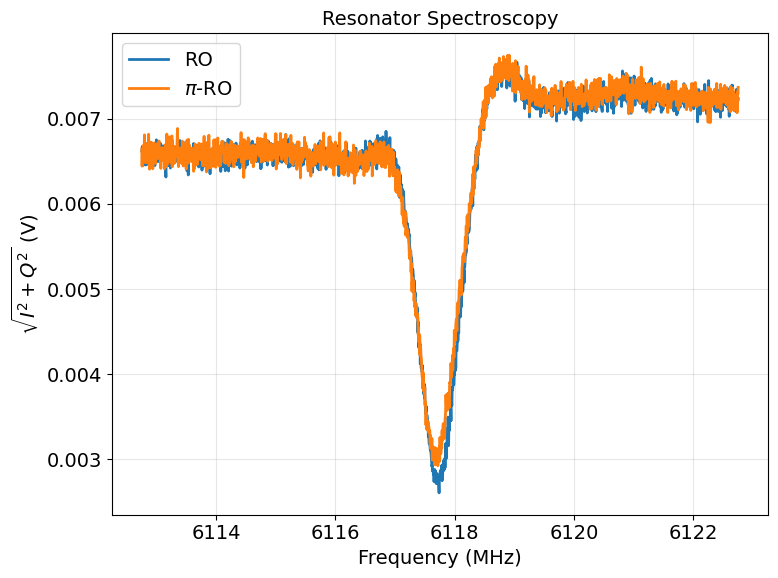

f_RO    = 6117.739062 MHz
f_π-RO  = 6117.719062 MHz
χ       = -0.010000 MHz


In [60]:
plt.figure(figsize=(8, 6))

plt.plot(freq_vector / 1e6, S21_mag_RO, label="RO", lw=2)
plt.plot(freq_vector / 1e6, S21_mag_PI_RO, label=r"$\pi$-RO", lw=2)

plt.xlabel("Frequency (MHz)")
plt.ylabel(r"$\sqrt{I^2 + Q^2}$ (V)")
plt.title("Resonator Spectroscopy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# calculate \chi
f_RO = freq_vector[np.argmin(S21_mag_dB_RO)]
f_PI_RO = freq_vector[np.argmin(S21_mag_dB_PI_RO)]

chi = (f_PI_RO - f_RO) / 2

print(f"f_RO    = {f_RO/1e6:.6f} MHz")
print(f"f_π-RO  = {f_PI_RO/1e6:.6f} MHz")
print(f"χ       = {chi/1e6:.6f} MHz")

In [61]:
data = np.load("data/2026-06-22/#1774_time_rabi_chevron_f12_151208/arrays.npz")

freq_vector = data["frequencies"]
pulse_len = data["durations"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag_matrix = np.sqrt(I_matrix**2 + Q_matrix**2)



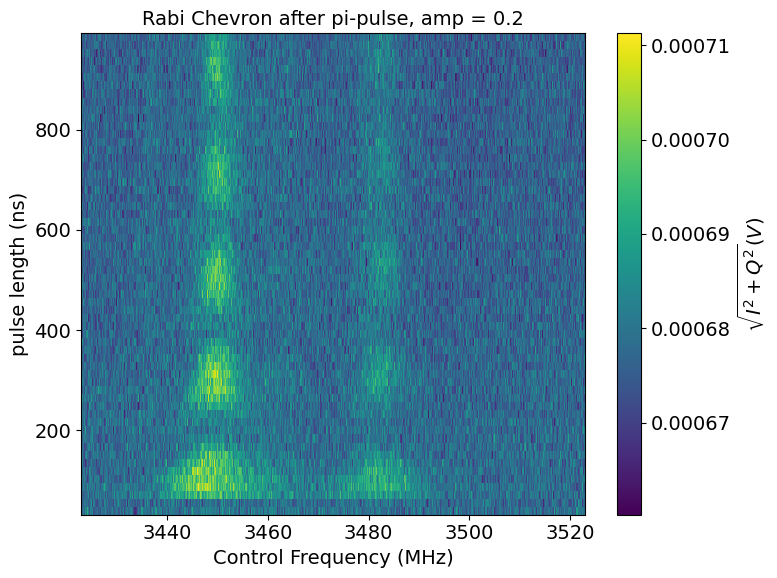

In [62]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    pulse_len*4,
    S21_mag_matrix,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel(r"pulse length (ns)")
plt.title("Rabi Chevron after pi-pulse, amp = 0.2")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [63]:
data = np.load("data/2026-06-24/#1843_T2E_histogram_142811/arrays.npz")

T2_vector = data["T1_values"] # ns
tau_vector = 4 * data["taus"] # ns
I_matrix = data["I_all"] # V
Q_matrix = data["Q_all"] # V



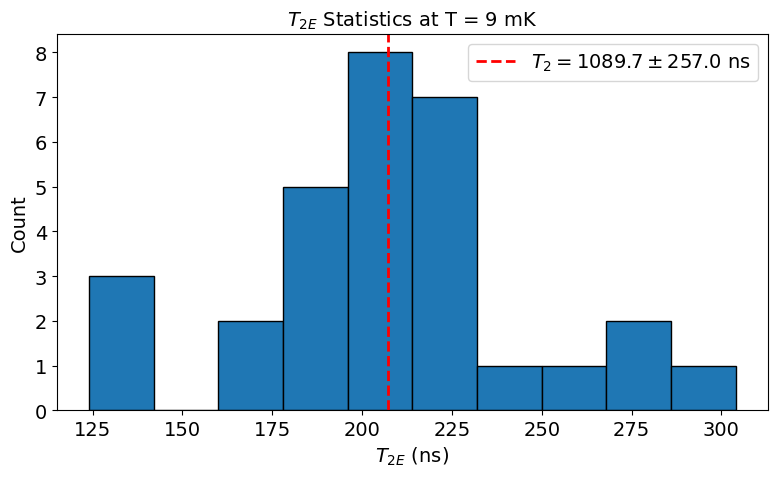

In [64]:
fig, ax = plt.subplots(figsize=(8,5))

# Statistics
T2_ave = np.mean(T2_vector)
T2_std = np.std(T2_vector)
Temp = 9
ax.hist(T2_vector, bins=10, edgecolor="black")

ax.axvline(
    T2_ave,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"$T_2 = {T1_ave:.1f} \pm {T1_std:.1f}$ ns"
)

ax.set_title(r"$T_{2E}$ Statistics at T = 9 mK")
ax.set_xlabel(r"$T_{2E}$ (ns)")
ax.set_ylabel("Count")

ax.legend()

fig.tight_layout()

plt.show()

# print(f"T1_ave = {T1_ave:.2f} ns")
# print(f"T1_std = {T1_std:.2f} ns")

In [65]:
# # Exponential decay model
# def exp_decay(t, A, T2, C):
#     return A * np.exp(-t / T2) + C

# for idx in range(len(T2_vector)):

#     T2_val = T2_vector[idx]

#     I_vector = I_matrix[idx, :]
#     Q_vector = Q_matrix[idx, :]

#     # Initial guesses
#     p0 = [
#         np.max(Q_vector) - np.min(Q_vector),
#         tau_vector.max() / 2,
#         np.min(Q_vector)
#     ]

#     try:
#         # Fit
#         popt, pcov = curve_fit(
#             exp_decay,
#             tau_vector,
#             Q_vector,
#             p0=p0,
#             maxfev=10000
#         )

#         A_fit, T2_fit, C_fit = popt
#         T2_err = np.sqrt(np.diag(pcov))[1]

#         # Smooth fit curve
#         tau_fit = np.linspace(
#             tau_vector.min(),
#             tau_vector.max(),
#             500
#         )
#         Q_fit = exp_decay(tau_fit, *popt)

#         # New figure for this decay
#         fig, ax = plt.subplots(figsize=(7, 5))

#         ax.scatter(
#             tau_vector,
#             Q_vector,
#             color="C0"
#         )

#         ax.plot(
#             tau_fit,
#             Q_fit,
#             color="C1",
#             lw=2,
#             label=rf"Fit: $T2E = {T2_fit:.1f} \pm {T2_err:.1f}$ [ns]"
#         )

#         ax.set_xlabel(r"$\tau$ [ns]")
#         ax.set_ylabel("Q [V]")
#         ax.set_title(rf"Decay data for $T2E = {T2_val:.1f}$ [ns]")

#         ax.legend()

#         fig.tight_layout()
#         plt.show()

#     except RuntimeError:
#         print(f"Fit failed for T2E = {T2_val}")

In [66]:
data = np.load("data/2026-06-24/#1878_resonator_spectroscopy_170437/arrays.npz")

freq_vector = data["frequency"]
I_vector_RO = data["I_data"]
Q_vector_RO = data["Q_data"]

S21_RO = I_vector_RO + 1j * Q_vector_RO
S21_mag_RO = np.abs(S21_RO)
S21_mag_dB_RO = 10 * np.log10(np.abs(S21_RO) ** 2)



In [67]:
data = np.load("data/2026-06-24/#1879_resonator_spectroscopy_pi_pulse_170450/arrays.npz")

freq_vector = data["frequency"]
I_vector_PI_RO = data["I_data"]
Q_vector_PI_RO = data["Q_data"]

S21_PI_RO = I_vector_PI_RO + 1j * Q_vector_PI_RO
S21_mag_PI_RO = np.abs(S21_PI_RO)
S21_mag_dB_PI_RO = 10 * np.log10(np.abs(S21_PI_RO) ** 2)



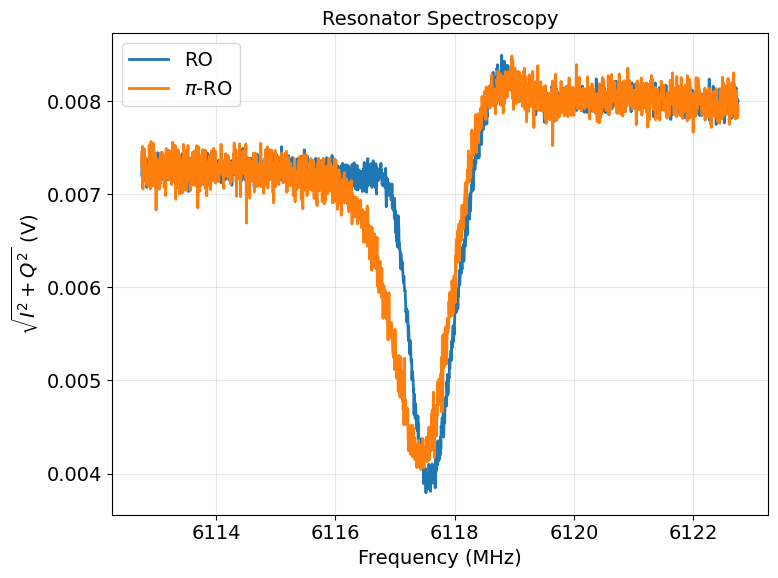

f_RO    = 6117.519062 MHz
f_π-RO  = 6117.434062 MHz
χ       = -0.042500 MHz


In [68]:
plt.figure(figsize=(8, 6))

plt.plot(freq_vector / 1e6, S21_mag_RO, label="RO", lw=2)
plt.plot(freq_vector / 1e6, S21_mag_PI_RO, label=r"$\pi$-RO", lw=2)

plt.xlabel("Frequency (MHz)")
plt.ylabel(r"$\sqrt{I^2 + Q^2}$ (V)")
plt.title("Resonator Spectroscopy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# calculate \chi
f_RO = freq_vector[np.argmin(S21_mag_dB_RO)]
f_PI_RO = freq_vector[np.argmin(S21_mag_dB_PI_RO)]

chi = (f_PI_RO - f_RO) / 2

print(f"f_RO    = {f_RO/1e6:.6f} MHz")
print(f"f_π-RO  = {f_PI_RO/1e6:.6f} MHz")
print(f"χ       = {chi/1e6:.6f} MHz")

In [90]:
data = np.load("data/2026-06-26/#1903_qubit_spectroscopy_stats_080421/arrays.npz")

reps = range(np.shape(I_matrix)[0])
freq_vector = data["frequency"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.abs(I_matrix**2 + Q_matrix**2)


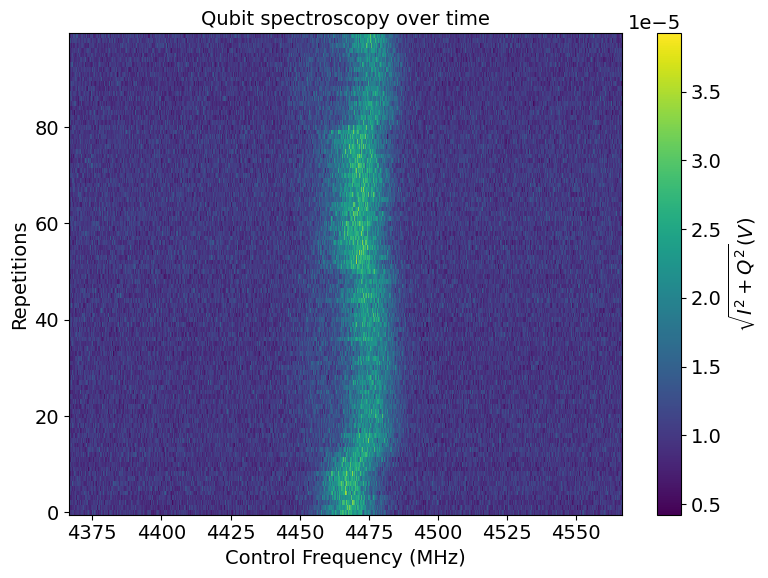

In [94]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    reps,
    S21_mag,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Repetitions")
plt.title("Qubit spectroscopy over time")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [105]:
data = np.load("data/2026-06-26/#1906_qubit_spectroscopy_stats_race_123431/arrays.npz")

reps = range(np.shape(I_matrix)[0])
freq_vector = data["frequency"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.sqrt(I_matrix**2 + Q_matrix**2)

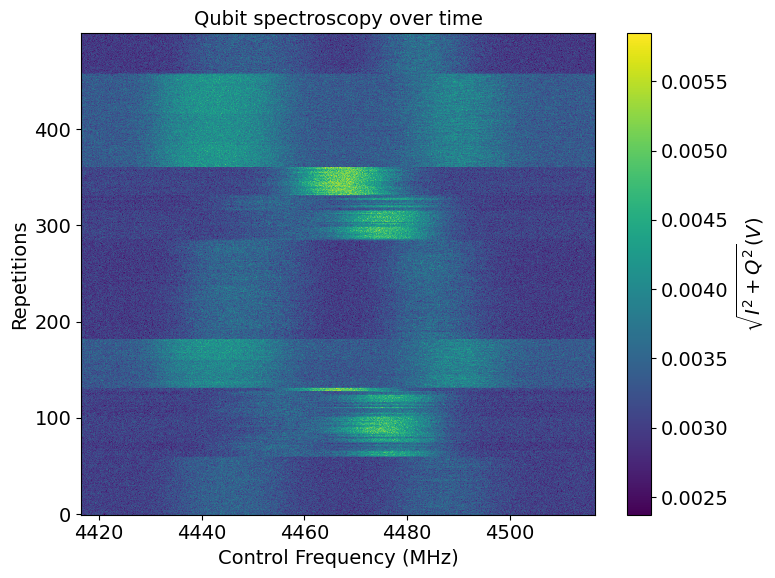

In [106]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    reps,
    S21_mag,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Repetitions")
plt.title("Qubit spectroscopy over time")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

In [112]:
data = np.load("data/2026-06-29/#1908_qubit_spectroscopy_stats_race_092215/arrays.npz")

reps = range(np.shape(I_matrix)[0])
freq_vector = data["frequency"]
I_matrix = data["I_data"]
Q_matrix = data["Q_data"]

S21_mag = np.sqrt(I_matrix**2 + Q_matrix**2)

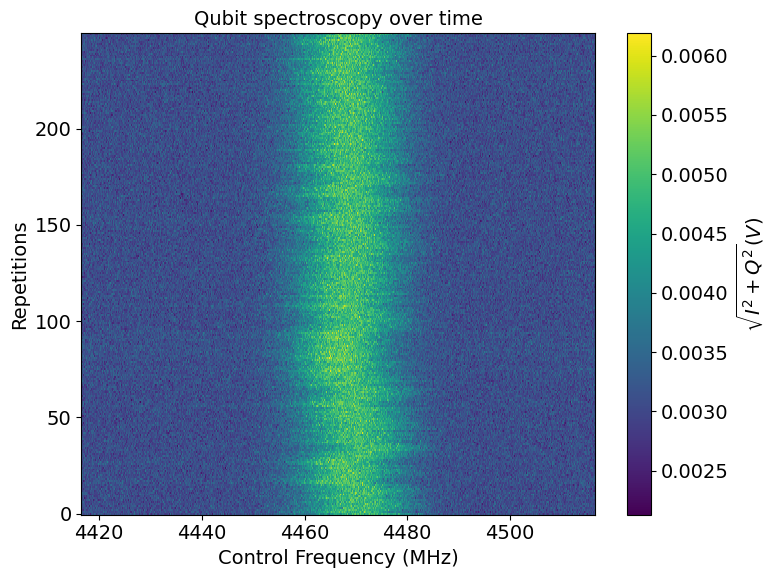

In [113]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq_vector/1e6,
    reps,
    S21_mag,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Repetitions")
plt.title("Qubit spectroscopy over time")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()

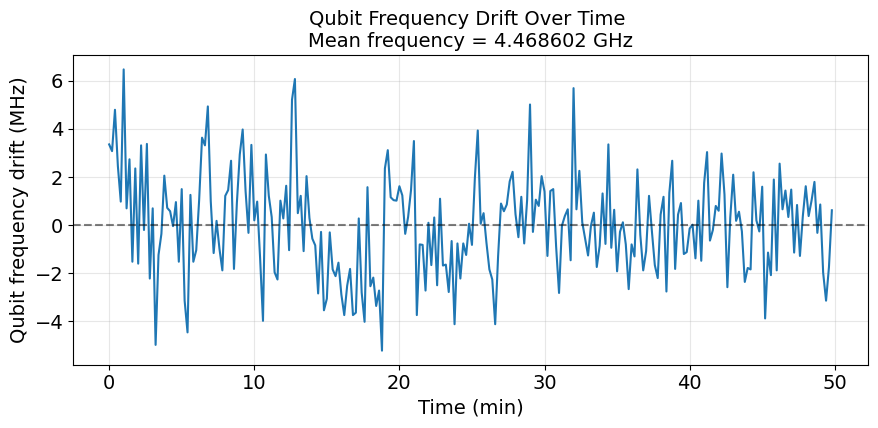

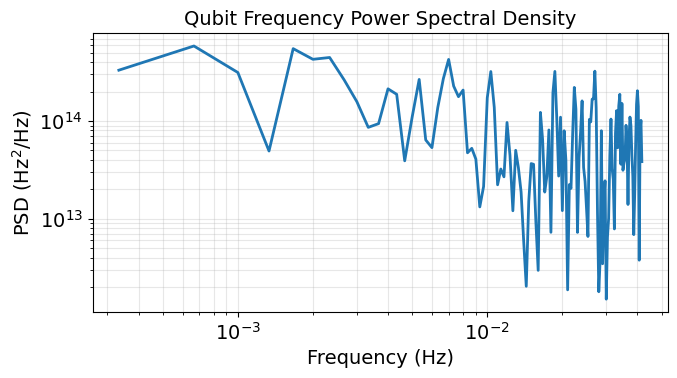

In [133]:
freq_qubit = np.empty(S21_mag.shape[0])

for i in range(S21_mag.shape[0]):
    max_idx = np.argmax(S21_mag[i])
    freq_qubit[i] = freq_vector[max_idx]

dt = 12.0  # seconds
time = np.arange(len(freq_qubit)) * dt

# Mean frequency and drift
freq_mean = np.mean(freq_qubit)
freq_drift = freq_qubit - freq_mean

# ---------------------------------------------------
# Plot frequency drift vs time
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(time/60, freq_drift/1e6, lw=1.5)
ax.axhline(0, color='k', ls='--', alpha=0.5)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Qubit frequency drift (MHz)")
ax.set_title(
    f"Qubit Frequency Drift Over Time \nMean frequency = {freq_mean/1e9:.6f} GHz"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Power Spectral Density
# ---------------------------------------------------
fs = 1 / dt

f_psd, psd = welch(
    freq_drift,
    fs=fs,
    window='hann',
    nperseg=min(256, len(freq_drift)),
    detrend='constant'
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.loglog(f_psd[1:], psd[1:], lw=2)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"PSD (Hz$^2$/Hz)")
ax.set_title("Qubit Frequency Power Spectral Density")
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [140]:
data = np.load("data/2026-06-30/#1921_ramsey_chevron_130246/arrays.npz")

freq = data["IF_frequencies"]
taus = data["taus"]
I = data["I_data"]
Q = data["Q_data"]

S21_mag = np.sqrt(I**2 + Q**2)

data

NpzFile 'data/2026-06-30/#1921_ramsey_chevron_130246/arrays.npz' with keys: IF_frequencies, taus, I_data, Q_data

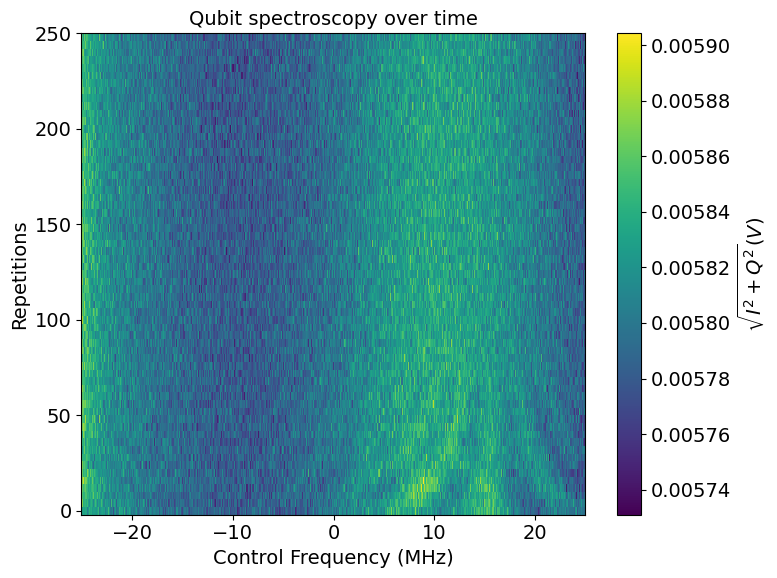

In [141]:
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    freq/1e6,
    taus,
    S21_mag,
    shading="auto"
)

plt.xlabel("Control Frequency (MHz)")
plt.ylabel("Repetitions")
plt.title("Qubit spectroscopy over time")
plt.colorbar(label=r"$\sqrt{I^2 + Q^2} (V)$")
plt.tight_layout()
plt.show()